In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

In [3]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [5]:
model = models.Sequential()

# Data Augmentation applied only during training
model.add(data_augmentation)

# 1st Convolution Block
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# 2nd Convolution Block
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))

# Dropout layer
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 63ms/step - accuracy: 0.2947 - loss: 1.9109 - val_accuracy: 0.5014 - val_loss: 1.3846
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 60ms/step - accuracy: 0.4510 - loss: 1.5167 - val_accuracy: 0.5435 - val_loss: 1.2738
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.5009 - loss: 1.4085 - val_accuracy: 0.5628 - val_loss: 1.2388
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.5164 - loss: 1.3520 - val_accuracy: 0.5974 - val_loss: 1.1184
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 58ms/step - accuracy: 0.5368 - loss: 1.3051 - val_accuracy: 0.6050 - val_loss: 1.0930
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 59ms/step - accuracy: 0.5485 - loss: 1.2729 - val_accuracy: 0.6325 - val_loss: 1.0296
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.5590 - loss: 1.2488 - val_accuracy: 0.6143 - val_loss: 1.0926
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.56

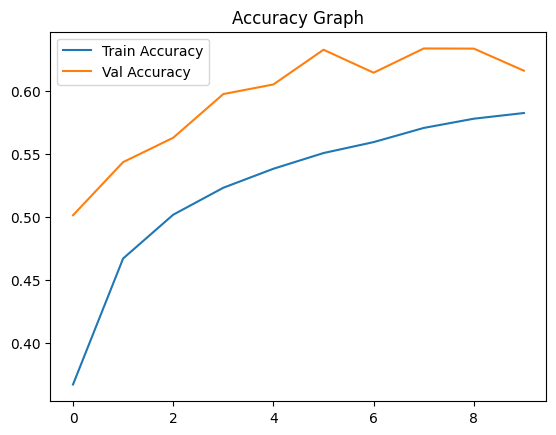

In [8]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
4